# Imports

In [23]:
import os
import gc
import json
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
from pathlib import Path
import matplotlib.pyplot as plt
from sklearn.utils import resample
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.metrics import Recall, Precision
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from sklearn.metrics import classification_report, confusion_matrix, precision_score

# Preparação do Dataset

In [2]:
# PASTAS_DATASET = [
#     '/content/drive/MyDrive/Unifei/7o-semestre/Computacao-Visual/Dataset/imagens_acrais_maligno',
#     '/content/drive/MyDrive/Unifei/7o-semestre/Computacao-Visual/Dataset/imagens_acrais_benignas'
# ]

PASTAS_DATASET = [
    '/home/gebra/Projetos Unifei/Visao-Computacional/imagens_acrais_maligno',
    '/home/gebra/Projetos Unifei/Visao-Computacional/imagens_acrais_benignas'
]

# EfficientNet-B0 utiliza 224x224
TAMANHO_IMAGEM = (224, 224)

In [3]:
# --- 2. CARREGAR E COMBINAR METADADOS ---
dfs = []
for pasta in PASTAS_DATASET:
    caminho_csv = os.path.join(pasta, 'metadata.csv')
    if os.path.exists(caminho_csv):
        df_temp = pd.read_csv(caminho_csv)
        # Cria uma nova coluna com o caminho completo da imagem para facilitar
        df_temp['caminho_imagem'] = df_temp['isic_id'].apply(lambda x: os.path.join(pasta, f"{x}.jpg"))
        dfs.append(df_temp)
    else:
        print(f"Aviso: {caminho_csv} não encontrado.")

# Junta os CSVs das duas pastas em um só DataFrame
df_completo = pd.concat(dfs, ignore_index=True)

In [4]:
# --- 3. FILTRAR DATASET (Usando todas as imagens disponíveis) ---
# 1. Primeiro, removemos duplicatas baseadas no ID único e verificamos existência física
df_unico = df_completo.drop_duplicates(subset='isic_id')
df_existente = df_unico[df_unico['caminho_imagem'].apply(os.path.exists)].copy()

# 2. Separar as classes sem limite de amostras
df_benigno = df_existente[df_existente['diagnosis_1'] == 'Benign']
df_maligno = df_existente[df_existente['diagnosis_1'] == 'Malignant']

# 3. Combinar e embaralhar o dataset final com tudo que foi encontrado
df_filtrado = pd.concat([df_benigno, df_maligno]).sample(frac=1, random_state=42).reset_index(drop=True)

print(f"Dataset total criado com {len(df_filtrado)} imagens (Benignas: {len(df_benigno)}, Malignas: {len(df_maligno)}).")

Dataset total criado com 2059 imagens (Benignas: 1557, Malignas: 502).


# Treinamento

In [14]:
print("=== DADOS: VALIDAÇÃO (20% do df_filtrado) + TREINO EQUILIBRADO (oversampling) ===")

TAMANHO_B0 = (224, 224)
BATCH_SIZE = 32

# Validação: 20% do df_filtrado, sem augmentation (métricas mais estáveis)
datagen_val = ImageDataGenerator(validation_split=0.2)
val_gen = datagen_val.flow_from_dataframe(
    dataframe=df_filtrado,
    x_col="caminho_imagem",
    y_col="diagnosis_1",
    target_size=TAMANHO_B0,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    subset="validation",
    shuffle=False,
)

# Oversampling da classe minoritária até igualar a majoritária
df_malignant = df_filtrado[df_filtrado["diagnosis_1"] == "Malignant"]
df_benign = df_filtrado[df_filtrado["diagnosis_1"] == "Benign"]
maior_classe = max(len(df_malignant), len(df_benign))
df_benign_upsampled = resample(
    df_benign, replace=True, n_samples=maior_classe, random_state=42
)
df_malignant_upsampled = resample(
    df_malignant, replace=True, n_samples=maior_classe, random_state=42
)
df_equilibrado = pd.concat([df_malignant_upsampled, df_benign_upsampled]).sample(
    frac=1, random_state=42
).reset_index(drop=True)

print(f"Treino equilibrado: {len(df_equilibrado)} imagens")
print(df_equilibrado["diagnosis_1"].value_counts())

# Treino: augmentation em todas as amostras de df_equilibrado (sem validation_split aqui)
# datagen_balanced = ImageDataGenerator(
#     rotation_range=360,
#     horizontal_flip=True,
#     vertical_flip=True,
#     width_shift_range=0.15,
#     height_shift_range=0.15,
#     zoom_range=[0.85, 1.15],
#     shear_range=0.1,
#     brightness_range=[0.8, 1.2],
#     channel_shift_range=20.0,
#     fill_mode="reflect",
# )

# datagen_balanced = ImageDataGenerator(
#     rotation_range=360,
#     horizontal_flip=True,
#     vertical_flip=True,
#     width_shift_range=0.0,
#     height_shift_range=0.0,
#     zoom_range=[0.0,0.0],
#     shear_range=0.1,
#     brightness_range=[0.0, 0.0],
#     channel_shift_range=20.0,
#     fill_mode="reflect",
# )

datagen_balanced = ImageDataGenerator(
    rotation_range=360,
    horizontal_flip=True,
    vertical_flip=True,
    fill_mode="reflect",
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=[0.9, 1.1],
    brightness_range=(0.85, 1.15),
    shear_range=0.08,
    channel_shift_range=15.0,
)

train_gen_balanced = datagen_balanced.flow_from_dataframe(
    dataframe=df_equilibrado,
    x_col="caminho_imagem",
    y_col="diagnosis_1",
    target_size=TAMANHO_B0,
    batch_size=BATCH_SIZE,
    class_mode="binary",
)

print("\n=== EfficientNet-B0 do zero (ImageNet na base, cabeçalho novo) ===")
base_model = EfficientNetB0(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3),
)
base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
saida = Dense(1, activation="sigmoid")(x)
modelo_cnn = Model(inputs=base_model.input, outputs=saida)

modelo_cnn.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="binary_crossentropy",
    metrics=["accuracy", Recall(name="recall")],
)

callbacks_fit = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_recall",
        mode="max",
        patience=5,
        restore_best_weights=True,
        verbose=1,
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss", factor=0.5, patience=2, min_lr=1e-7, verbose=1
    ),
]

print("\n=== TREINAMENTO (única fase) ===")
history_balanced = modelo_cnn.fit(
    train_gen_balanced,
    validation_data=val_gen,
    epochs=15,
    callbacks=callbacks_fit,
)

print("\nTreinamento concluído.")


=== DADOS: VALIDAÇÃO (20% do df_filtrado) + TREINO EQUILIBRADO (oversampling) ===
Found 411 validated image filenames belonging to 2 classes.


Treino equilibrado: 3114 imagens
diagnosis_1
Malignant    1557
Benign       1557
Name: count, dtype: int64
Found 3114 validated image filenames belonging to 2 classes.

=== EfficientNet-B0 do zero (ImageNet na base, cabeçalho novo) ===

=== TREINAMENTO (única fase) ===
Epoch 1/15
98/98 ━━━━━━━━━━━━━━━━━━━━ 120s 1s/step - accuracy: 0.6904 - loss: 0.6151 - recall: 0.6159 - val_accuracy: 0.7324 - val_loss: 0.5832 - val_recall: 0.8571 - learning_rate: 1.0000e-04
Epoch 2/15
98/98 ━━━━━━━━━━━━━━━━━━━━ 116s 1s/step - accuracy: 0.8388 - loss: 0.4697 - recall: 0.8606 - val_accuracy: 0.8418 - val_loss: 0.4779 - val_recall: 0.9082 - learning_rate: 1.0000e-04
Epoch 3/15
98/98 ━━━━━━━━━━━━━━━━━━━━ 113s 1s/step - accuracy: 0.8574 - loss: 0.4051 - recall: 0.8658 - val_accuracy: 0.8686 - val_loss: 0.4246 - val_recall: 0.9490 - learning_rate: 1.0000e-04
Epoch 4/15
98/98 ━━━━━━━━━━━━━━━━━━━━ 105s 1s/step - accuracy: 0.8613 - loss: 0.3706 - recall: 0.8626 - val_accuracy: 0.8808 - val_loss: 0.3954 - val_r

# Teste em Imagens

=== Teste em 5 imagens: predição vs rótulo real ===


,arquivo,P(maligno),predição,rótulo correto,acertou?
0,ISIC_0064667.jpg,0.8543,Malignant,Malignant,True
1,ISIC_6193854.jpg,0.4611,Benign,Benign,True
2,ISIC_7325047.jpg,0.1854,Benign,Benign,True
3,ISIC_9967358.jpg,0.8136,Malignant,Malignant,True
4,ISIC_0056728.jpg,0.6245,Malignant,Malignant,True


Acertos: 5 / 5


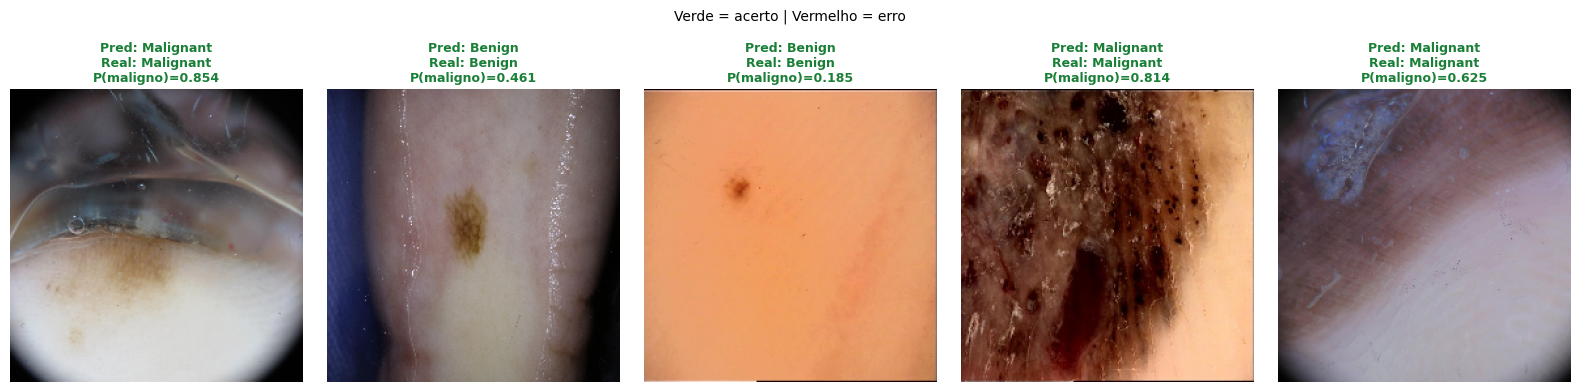

In [24]:
print("=== Teste em 5 imagens: predição vs rótulo real ===")

N_TESTE = 5
amostras = df_filtrado.sample(n=N_TESTE)[
    ["caminho_imagem", "diagnosis_1"]
].reset_index(drop=True)

h, w = TAMANHO_B0[0], TAMANHO_B0[1]
batch = np.zeros((N_TESTE, h, w, 3), dtype=np.float32)
for i, row in amostras.iterrows():
    img = load_img(row["caminho_imagem"], target_size=(h, w))
    batch[i] = img_to_array(img)

# Mesmo formato que o ImageDataGenerator (sem rescale): pixels em [0, 255]
probs = modelo_cnn.predict(batch, verbose=0).flatten()
# class_mode='binary' com strings ordena alfabeticamente: 0=Benign, 1=Malignant
pred_classe = np.where(probs >= 0.5, "Malignant", "Benign")

tabela = pd.DataFrame(
    {
        "arquivo": amostras["caminho_imagem"].map(os.path.basename),
        "P(maligno)": np.round(probs, 4),
        "predição": pred_classe,
        "rótulo correto": amostras["diagnosis_1"].values,
        "acertou?": pred_classe == amostras["diagnosis_1"].values,
    }
)
display(tabela)
print(f"Acertos: {tabela['acertou?'].sum()} / {N_TESTE}")

fig, axes = plt.subplots(1, N_TESTE, figsize=(3.2 * N_TESTE, 3.8))
axes = np.atleast_1d(axes)
for i in range(N_TESTE):
    ax = axes[i]
    ax.imshow(np.clip(batch[i], 0, 255).astype(np.uint8))
    ax.set_axis_off()
    verdade = amostras["diagnosis_1"].iloc[i]
    acertou = pred_classe[i] == verdade
    cor = "#1a7f37" if acertou else "#b42318"
    ax.set_title(
        f"Pred: {pred_classe[i]}\nReal: {verdade}\nP(maligno)={probs[i]:.3f}",
        fontsize=9,
        color=cor,
        fontweight="bold",
    )
fig.suptitle("Verde = acerto | Vermelho = erro", fontsize=10, y=1.02)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


# Teste de argumentos para ImageDataGenerator

In [ ]:
print("=== BUSCA RÁPIDA: variação automática de augmentação (épocas curtas) ===")
print("Requer: célula anterior executada (df_filtrado, df_equilibrado, val_gen, TAMANHO_B0, BATCH_SIZE).")
print(
    "Ranking por precision_malignant. CSV/JSON são gravados após cada config; "
    "Ctrl+C salva o que já terminou (a config em andamento no fit pode ser perdida)."
)

# Treino isolado da célula anterior: não reutiliza `modelo_cnn` nem `history_balanced`.
# Cada config = clear_session + novo grafo. EfficientNetB0 carrega só ImageNet na base
# (congelada); o cabeçalho GAP → Dense(1) é sempre criado do zero (pesos aleatórios).

EPOCHS_SWEEP = 6
OUT_CSV = Path.cwd() / "augment_hparam_sweep.csv"
OUT_JSON = Path.cwd() / "augment_hparam_sweep.json"


def persist_sweep(rows):
    """Grava CSV + JSON ranqueados por precisão na classe Malignant (resultado parcial a cada config)."""
    if not rows:
        return
    df = pd.DataFrame(rows)
    df = df.sort_values("precision_malignant", ascending=False).reset_index(drop=True)
    df.insert(0, "rank_precision_malignant", range(1, len(df) + 1))
    df.to_csv(OUT_CSV, index=False)
    with open(OUT_JSON, "w", encoding="utf-8") as f:
        json.dump(df.to_dict("records"), f, indent=2, ensure_ascii=False, default=float)
    print(
        f"  → Parcial salvo ({len(rows)} config(s)) — ranking por precision_malignant: {OUT_CSV.resolve()}"
    )


# Pequena grade de parâmetros discutidos (geométricos + fotométricos)
AUGMENT_CONFIGS = [
    {
        "name": "weak_atual",
        "width_shift_range": 0.0,
        "height_shift_range": 0.0,
        "zoom_range": (0.0, 0.0),
        "brightness_range": (0.0, 0.0),
        "shear_range": 0.1,
        "channel_shift_range": 20.0,
        "learning_rate": 1e-3,
    },
    {
        "name": "forte_comentario_notebook",
        "width_shift_range": 0.15,
        "height_shift_range": 0.15,
        "zoom_range": (0.85, 1.15),
        "brightness_range": (0.8, 1.2),
        "shear_range": 0.1,
        "channel_shift_range": 20.0,
        "learning_rate": 1e-3,
    },
    {
        "name": "moderado",
        "width_shift_range": 0.1,
        "height_shift_range": 0.1,
        "zoom_range": (0.9, 1.1),
        "brightness_range": (0.85, 1.15),
        "shear_range": 0.08,
        "channel_shift_range": 15.0,
        "learning_rate": 1e-3,
    },
    {
        "name": "geom_forte_foto_leve",
        "width_shift_range": 0.15,
        "height_shift_range": 0.15,
        "zoom_range": (0.85, 1.15),
        "brightness_range": (0.92, 1.08),
        "shear_range": 0.1,
        "channel_shift_range": 10.0,
        "learning_rate": 1e-3,
    },
    {
        "name": "foto_forte_geom_leve",
        "width_shift_range": 0.05,
        "height_shift_range": 0.05,
        "zoom_range": (0.95, 1.05),
        "brightness_range": (0.75, 1.25),
        "shear_range": 0.05,
        "channel_shift_range": 25.0,
        "learning_rate": 1e-3,
    },
    {
        "name": "forte_lr_5e4",
        "width_shift_range": 0.15,
        "height_shift_range": 0.15,
        "zoom_range": (0.85, 1.15),
        "brightness_range": (0.8, 1.2),
        "shear_range": 0.1,
        "channel_shift_range": 20.0,
        "learning_rate": 5e-4,
    },
]

sweep_rows = []

for i, cfg_template in enumerate(AUGMENT_CONFIGS):
    cfg = dict(cfg_template)
    name = cfg["name"]
    lr = float(cfg.pop("learning_rate"))
    model_sweep = None

    try:
        tf.keras.backend.clear_session()

        datagen = ImageDataGenerator(
            rotation_range=360,
            horizontal_flip=True,
            vertical_flip=True,
            fill_mode="reflect",
            width_shift_range=cfg["width_shift_range"],
            height_shift_range=cfg["height_shift_range"],
            zoom_range=list(cfg["zoom_range"]),
            brightness_range=list(cfg["brightness_range"]),
            shear_range=cfg["shear_range"],
            channel_shift_range=cfg["channel_shift_range"],
        )
        train_gen = datagen.flow_from_dataframe(
            dataframe=df_equilibrado,
            x_col="caminho_imagem",
            y_col="diagnosis_1",
            target_size=TAMANHO_B0,
            batch_size=BATCH_SIZE,
            class_mode="binary",
        )

        base = EfficientNetB0(
            weights="imagenet",
            include_top=False,
            input_shape=(224, 224, 3),
        )
        base.trainable = False
        x = base.output
        x = GlobalAveragePooling2D(name="sweep_gap")(x)
        out = Dense(
            1,
            activation="sigmoid",
            name="sweep_dense_head",
            kernel_initializer="glorot_uniform",
            bias_initializer="zeros",
        )(x)
        model_sweep = Model(inputs=base.input, outputs=out, name="model_sweep_isolado")
        model_sweep.compile(
            optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
            loss="binary_crossentropy",
            metrics=["accuracy", Recall(name="recall"), Precision(name="precision")],
        )

        cb = [
            tf.keras.callbacks.EarlyStopping(
                monitor="val_loss",
                mode="min",
                patience=3,
                restore_best_weights=True,
                verbose=0,
            ),
        ]

        print(f"\n--- [{i + 1}/{len(AUGMENT_CONFIGS)}] {name} | lr={lr} ---")
        hist = model_sweep.fit(
            train_gen,
            validation_data=val_gen,
            epochs=EPOCHS_SWEEP,
            callbacks=cb,
            verbose=1,
        )

        val_gen.reset()
        y_prob = model_sweep.predict(val_gen, verbose=0).flatten()
        y_pred = (y_prob > 0.5).astype(int)
        y_true = val_gen.classes
        labels = list(val_gen.class_indices.keys())

        rep = classification_report(
            y_true, y_pred, target_names=labels, output_dict=True, zero_division=0
        )
        prec_macro = precision_score(y_true, y_pred, average="macro", zero_division=0)
        prec_weighted = precision_score(
            y_true, y_pred, average="weighted", zero_division=0
        )

        last = {k: float(v[-1]) for k, v in hist.history.items()}
        best_val_loss = float(min(hist.history["val_loss"]))
        best_epoch_loss = int(np.argmin(hist.history["val_loss"])) + 1

        row = {
            "config_name": name,
            "learning_rate": lr,
            "width_shift_range": cfg["width_shift_range"],
            "height_shift_range": cfg["height_shift_range"],
            "zoom_low": cfg["zoom_range"][0],
            "zoom_high": cfg["zoom_range"][1],
            "brightness_low": cfg["brightness_range"][0],
            "brightness_high": cfg["brightness_range"][1],
            "shear_range": cfg["shear_range"],
            "channel_shift_range": cfg["channel_shift_range"],
            "epochs_ran": len(hist.history["loss"]),
            "best_val_loss": best_val_loss,
            "best_val_loss_epoch": best_epoch_loss,
            "val_accuracy_last": last.get("val_accuracy"),
            "precision_macro": prec_macro,
            "precision_weighted": prec_weighted,
            "precision_benign": rep["Benign"]["precision"],
            "precision_malignant": rep["Malignant"]["precision"],
            "recall_benign": rep["Benign"]["recall"],
            "recall_malignant": rep["Malignant"]["recall"],
            "f1_macro": float(
                np.mean([rep["Benign"]["f1-score"], rep["Malignant"]["f1-score"]])
            ),
        }
        sweep_rows.append(row)

    except KeyboardInterrupt:
        print(
            "\nInterrompido (Ctrl+C). Configurações já concluídas foram gravadas em:",
            OUT_CSV.resolve(),
        )
        raise
    finally:
        if sweep_rows:
            persist_sweep(sweep_rows)
        if model_sweep is not None:
            del model_sweep
        gc.collect()

df_sweep = pd.DataFrame(sweep_rows)
df_sweep = df_sweep.sort_values("precision_malignant", ascending=False).reset_index(
    drop=True
)
df_sweep.insert(0, "rank_precision_malignant", range(1, len(df_sweep) + 1))

print("\n=== RESULTADO FINAL (ordenado por precision_malignant) ===")
print(df_sweep.to_string(index=False))
print(f"\nCSV (atualizado a cada config + ao interromper): {OUT_CSV.resolve()}")
print(f"JSON: {OUT_JSON.resolve()}")


=== BUSCA RÁPIDA: variação automática de augmentação (épocas curtas) ===
Requer: célula anterior executada (df_filtrado, df_equilibrado, val_gen, TAMANHO_B0, BATCH_SIZE).
Ranking por precision_malignant. CSV/JSON são gravados após cada config; Ctrl+C salva o que já terminou (a config em andamento no fit pode ser perdida).
Found 3114 validated image filenames belonging to 2 classes.

--- [1/6] weak_atual | lr=0.001 ---
Epoch 1/6
98/98 ━━━━━━━━━━━━━━━━━━━━ 113s 1s/step - accuracy: 0.5058 - loss: 0.6961 - precision: 0.5070 - recall: 0.4194 - val_accuracy: 0.7640 - val_loss: 0.5719 - val_precision: 0.5077 - val_recall: 0.3367
Epoch 2/6
98/98 ━━━━━━━━━━━━━━━━━━━━ 111s 1s/step - accuracy: 0.4900 - loss: 0.6970 - precision: 0.4898 - recall: 0.4804 - val_accuracy: 0.7445 - val_loss: 0.5957 - val_precision: 0.4478 - val_recall: 0.3061
Epoch 3/6
98/98 ━━━━━━━━━━━━━━━━━━━━ 111s 1s/step - accuracy: 0.5157 - loss: 0.6942 - precision: 0.5158 - recall: 0.5132 - val_accuracy: 0.7591 - val_loss: 0.5983

# Comparação dos argumentos

Arquivo: /home/gebra/Projetos Unifei/Visao-Computacional/Code/augment_hparam_sweep.csv
Configs avaliadas: 6

Tabela (ordenada como no CSV):


,rank_precision_malignant,config_name,precision_malignant,recall_malignant,precision_benign,recall_benign,precision_macro,val_accuracy_last,best_val_loss
0,1,moderado,0.729323,0.989796,0.996403,0.884984,0.862863,0.902676,0.270733
1,2,geom_forte_foto_leve,0.723881,0.989796,0.996390,0.881789,0.860135,0.907543,0.254348
2,3,foto_forte_geom_leve,0.716418,0.979592,0.992780,0.878594,0.854599,0.900243,0.254897
3,4,forte_comentario_notebook,0.705882,0.979592,0.992727,0.872204,0.849305,0.907543,0.257867
4,5,forte_lr_5e4,0.702899,0.989796,0.996337,0.869010,0.849618,0.888078,0.285936
5,6,weak_atual,0.507692,0.336735,0.812139,0.897764,0.659916,0.756691,0.571887



--- Resumo ---
Melhor config (rank 1): moderado — precision_malignant=0.7293, recall_malignant=0.9898
Última no ranking: weak_atual — precision_malignant=0.5077
Amplitude precision_malignant (max−min): 0.2216

Correlação (Pearson) com precision_malignant (|ρ| maior = mais ligado neste sweep):


,corr
val_accuracy_last,0.992707
best_val_loss,-0.992310
zoom_low,0.991748
brightness_low,0.989936
zoom_high,0.985326
brightness_high,0.978034
epochs_ran,0.833986
height_shift_range,0.741188
width_shift_range,0.741188
best_val_loss_epoch,0.699173


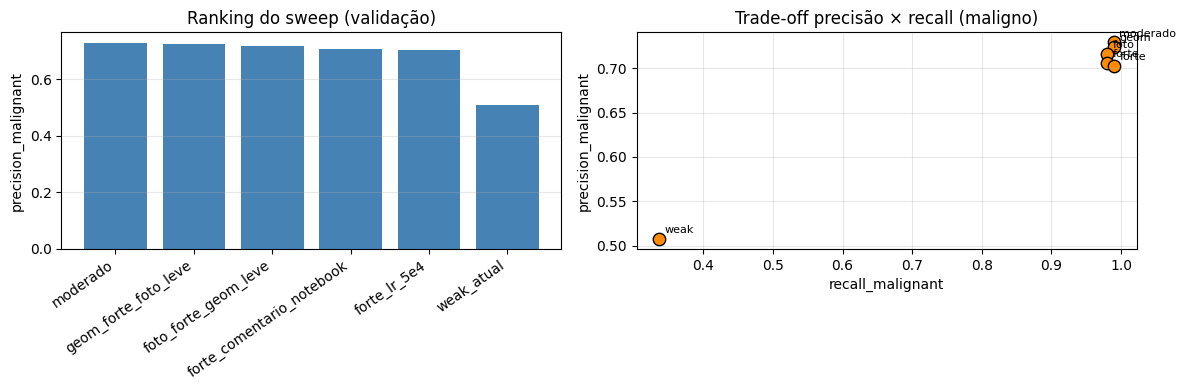


--- Leitura rápida (neste CSV) ---
• O sweep ranqueou por precision_malignant; verifique se o recall maligno ainda é aceitável clinicamente.
• Configs com shift/zoom/brilho moderados superaram 'weak_atual' (sem jitter geométrico/fotométrico), alinhado à ideia de maior invariância de captura.
• Correlações acima são exploratórias (poucas amostras); use como pista para afinar a próxima grade, não como prova causal.


In [ ]:
# === Análise: resultados do sweep (Code/augment_hparam_sweep.csv) ===
_candidates = [
    Path("Code") / "augment_hparam_sweep.csv",
    Path("augment_hparam_sweep.csv"),
    Path.cwd() / "Code" / "augment_hparam_sweep.csv",
    Path.cwd() / "augment_hparam_sweep.csv",
]
CSV_SWEEP = next((p.resolve() for p in _candidates if p.exists()), None)
if CSV_SWEEP is None:
    raise FileNotFoundError(
        "Não achei augment_hparam_sweep.csv. Rode a célula do sweep ou ajuste o caminho."
    )

df = pd.read_csv(CSV_SWEEP)
print(f"Arquivo: {CSV_SWEEP}")
print(f"Configs avaliadas: {len(df)}")

# Métricas-chave (ranking do sweep = precision_malignant)
cols_show = [
    "rank_precision_malignant",
    "config_name",
    "precision_malignant",
    "recall_malignant",
    "precision_benign",
    "recall_benign",
    "precision_macro",
    "val_accuracy_last",
    "best_val_loss",
]
print("\nTabela (ordenada como no CSV):")
display(df[cols_show])

best = df.iloc[0]
worst = df.iloc[-1]
spread = float(df["precision_malignant"].max() - df["precision_malignant"].min())
print("\n--- Resumo ---")
print(
    f"Melhor config (rank 1): {best['config_name']} — precision_malignant={best['precision_malignant']:.4f}, "
    f"recall_malignant={best['recall_malignant']:.4f}"
)
print(
    f"Última no ranking: {worst['config_name']} — precision_malignant={worst['precision_malignant']:.4f}"
)
print(f"Amplitude precision_malignant (max−min): {spread:.4f}")

# Correlação simples (Pearson) entre hiperparâmetros numéricos e precision_malignant
num_cols = [
    c
    for c in df.columns
    if c
    not in (
        "rank_precision_malignant",
        "config_name",
        "precision_macro",
        "precision_weighted",
        "precision_benign",
        "precision_malignant",
        "recall_benign",
        "recall_malignant",
        "f1_macro",
    )
    and pd.api.types.is_numeric_dtype(df[c])
]
target = "precision_malignant"
corrs = df[num_cols].corrwith(df[target])
corrs = corrs.reindex(corrs.abs().sort_values(ascending=False).index)
print("\nCorrelação (Pearson) com precision_malignant (|ρ| maior = mais ligado neste sweep):")
display(corrs.to_frame("corr"))

# Figuras
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
order = df.sort_values(target, ascending=False)["config_name"]
dfo = df.set_index("config_name").loc[order]
x = np.arange(len(dfo))
axes[0].bar(x, dfo[target], color="steelblue")
axes[0].set_xticks(x)
axes[0].set_xticklabels(dfo.index, rotation=35, ha="right")
axes[0].set_ylabel("precision_malignant")
axes[0].set_title("Ranking do sweep (validação)")
axes[0].grid(axis="y", alpha=0.3)

axes[1].scatter(
    dfo["recall_malignant"],
    dfo[target],
    s=80,
    c="darkorange",
    edgecolors="k",
)
for i, name in enumerate(dfo.index):
    axes[1].annotate(
        name.split("_")[0],
        (dfo.loc[name, "recall_malignant"], dfo.loc[name, target]),
        textcoords="offset points",
        xytext=(4, 4),
        fontsize=8,
    )
axes[1].set_xlabel("recall_malignant")
axes[1].set_ylabel("precision_malignant")
axes[1].set_title("Trade-off precisão × recall (maligno)")
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(
    "\n--- Leitura rápida (neste CSV) ---\n"
    "• O sweep ranqueou por precision_malignant; verifique se o recall maligno ainda é aceitável clinicamente.\n"
    "• Configs com shift/zoom/brilho moderados superaram 'weak_atual' (sem jitter geométrico/fotométrico), "
    "alinhado à ideia de maior invariância de captura.\n"
    "• Correlações acima são exploratórias (poucas amostras); use como pista para afinar a próxima grade, não como prova causal."
)


=== Moderado (1º no sweep): treino curto + matriz de confusão (validação) ===
Requer células anteriores: df_equilibrado, val_gen, TAMANHO_B0, BATCH_SIZE.
Found 3114 validated image filenames belonging to 2 classes.
Epoch 1/6
98/98 ━━━━━━━━━━━━━━━━━━━━ 157s 2s/step - accuracy: 0.8507 - loss: 0.3680 - val_accuracy: 0.8978 - val_loss: 0.2982
Epoch 2/6
98/98 ━━━━━━━━━━━━━━━━━━━━ 146s 1s/step - accuracy: 0.8882 - loss: 0.2744 - val_accuracy: 0.9051 - val_loss: 0.2622
Epoch 3/6
98/98 ━━━━━━━━━━━━━━━━━━━━ 144s 1s/step - accuracy: 0.9017 - loss: 0.2458 - val_accuracy: 0.9124 - val_loss: 0.2446
Epoch 4/6
98/98 ━━━━━━━━━━━━━━━━━━━━ 138s 1s/step - accuracy: 0.9037 - loss: 0.2275 - val_accuracy: 0.9148 - val_loss: 0.2419
Epoch 5/6
98/98 ━━━━━━━━━━━━━━━━━━━━ 131s 1s/step - accuracy: 0.9091 - loss: 0.2206 - val_accuracy: 0.8905 - val_loss: 0.2810
Epoch 6/6
98/98 ━━━━━━━━━━━━━━━━━━━━ 160s 2s/step - accuracy: 0.9155 - loss: 0.2088 - val_accuracy: 0.9173 - val_loss: 0.2136
Restoring model weights from 

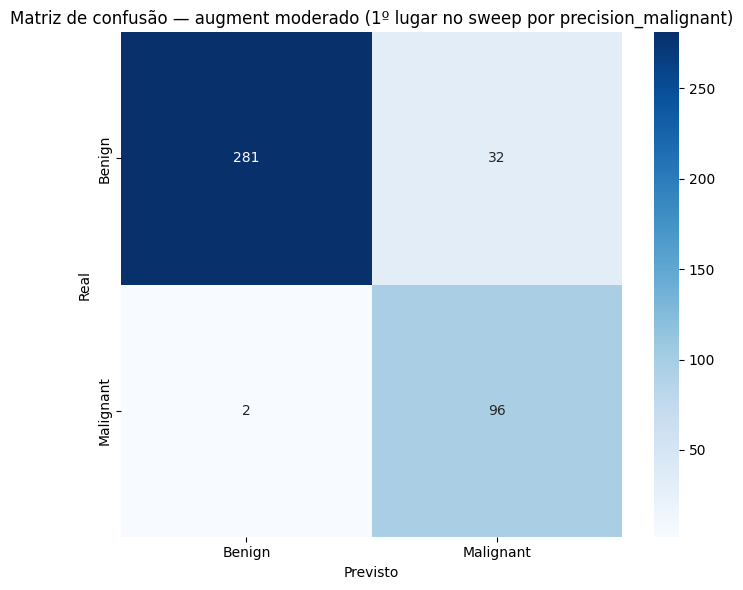

In [25]:
# Matriz de confusão na validação: apenas augment "moderado" (1º no sweep por precision_malignant).
# Treino isolado — não reutiliza `modelo_cnn` nem pesos do sweep anterior.

print(
    "=== Moderado (1º no sweep): treino curto + matriz de confusão (validação) ===\n"
    "Requer células anteriores: df_equilibrado, val_gen, TAMANHO_B0, BATCH_SIZE."
)

EPOCHS_MOD = 6  # alinhado ao EPOCHS_SWEEP da célula do sweep
LR_MOD = 1e-3

tf.keras.backend.clear_session()
gc.collect()

datagen_mod = ImageDataGenerator(
    rotation_range=360,
    horizontal_flip=True,
    vertical_flip=True,
    fill_mode="reflect",
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=[0.9, 1.1],
    brightness_range=(0.85, 1.15),
    shear_range=0.08,
    channel_shift_range=15.0,
)
train_gen_mod = datagen_mod.flow_from_dataframe(
    dataframe=df_equilibrado,
    x_col="caminho_imagem",
    y_col="diagnosis_1",
    target_size=TAMANHO_B0,
    batch_size=BATCH_SIZE,
    class_mode="binary",
)

base_mod = EfficientNetB0(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3),
)
base_mod.trainable = False
x = base_mod.output
x = GlobalAveragePooling2D(name="moderado_gap")(x)
out = Dense(
    1,
    activation="sigmoid",
    name="moderado_dense_head",
    kernel_initializer="glorot_uniform",
    bias_initializer="zeros",
)(x)
model_moderado = Model(inputs=base_mod.input, outputs=out, name="model_moderado_sweep1")
model_moderado.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LR_MOD),
    loss="binary_crossentropy",
    metrics=["accuracy"],
)

cb_mod = [
    EarlyStopping(
        monitor="val_loss",
        mode="min",
        patience=3,
        restore_best_weights=True,
        verbose=1,
    ),
]

hist_mod = model_moderado.fit(
    train_gen_mod,
    validation_data=val_gen,
    epochs=EPOCHS_MOD,
    callbacks=cb_mod,
    verbose=1,
)

val_gen.reset()
y_prob_mod = model_moderado.predict(val_gen, verbose=0).flatten()
y_pred_mod = (y_prob_mod > 0.5).astype(int)
y_true = val_gen.classes
class_labels = list(val_gen.class_indices.keys())

print("\nRelatório de classificação (validação) — augment moderado:")
print(
    classification_report(
        y_true,
        y_pred_mod,
        target_names=class_labels,
        digits=4,
        zero_division=0,
    )
)

cm_mod = confusion_matrix(y_true, y_pred_mod)
plt.figure(figsize=(7, 6))
sns.heatmap(
    cm_mod,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_labels,
    yticklabels=class_labels,
)
plt.title(
    "Matriz de confusão — augment moderado (1º lugar no sweep por precision_malignant)"
)
plt.ylabel("Real")
plt.xlabel("Previsto")
plt.tight_layout()
plt.show()


# Resultados Learning rate 1e-4

=== AVALIAÇÃO (validação = 20% do df_filtrado, sem oversampling) ===
13/13 ━━━━━━━━━━━━━━━━━━━━ 12s 869ms/step

Relatório de classificação:
              precision    recall  f1-score   support

      Benign     0.9926    0.8594    0.9212       313
   Malignant     0.6857    0.9796    0.8067        98

    accuracy                         0.8881       411
   macro avg     0.8392    0.9195    0.8640       411
weighted avg     0.9194    0.8881    0.8939       411



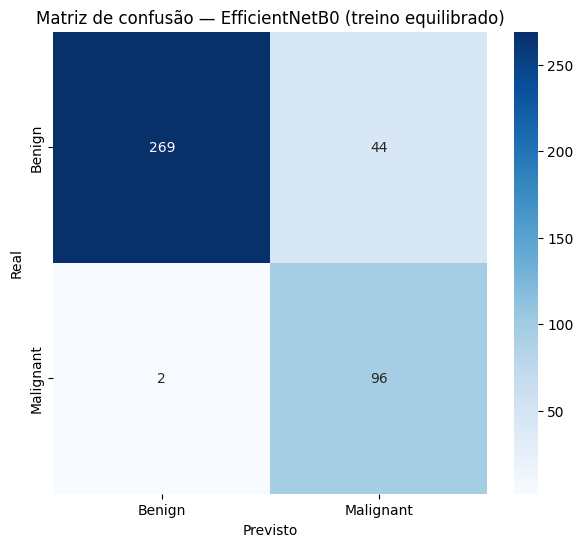

In [16]:
print("=== AVALIAÇÃO (validação = 20% do df_filtrado, sem oversampling) ===")

val_gen.reset()
y_pred_probs = modelo_cnn.predict(val_gen, verbose=1)
y_pred = (y_pred_probs > 0.5).astype(int).flatten()

y_true = val_gen.classes
class_labels = list(val_gen.class_indices.keys())

print("\nRelatório de classificação:")
print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_labels,
        digits=4,
    )
)

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(7, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_labels,
    yticklabels=class_labels,
)
plt.title("Matriz de confusão — EfficientNetB0 (treino equilibrado)")
plt.ylabel("Real")
plt.xlabel("Previsto")
plt.show()
